In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("ralston_hoerr_joc_1942.csv")
data

,SMILES,g/100gwaterat30
0,CCCCCC(=O)O,1.01900
1,CCCCCCC(=O)O,0.27100
2,CCCCCCCC(=O)O,0.07900
3,CCCCCCCCC(=O)O,0.03200
4,CCCCCCCCCC(=O)O,0.01800
5,CCCCCCCCCCC(=O)O,0.01100
6,CCCCCCCCCCCC(=O)O,0.00630
7,CCCCCCCCCCCCC(=O)O,0.00380
8,CCCCCCCCCCCCCC(=O)O,0.00240
9,CCCCCCCCCCCCCCC(=O)O,0.00140


In [3]:
from rdkit.Chem.Descriptors import MolWt
from rdkit.Chem import MolFromSmiles
import numpy as np

In [4]:
g_water_at_30_per_ml = 0.99567
ml_per_L = 1000
g_acid_per_mol = [MolWt(MolFromSmiles(s)) for s in data["SMILES"]]
data["logS"] = np.log10(data["g/100gwaterat30"] * g_water_at_30_per_ml * ml_per_L / np.array(g_acid_per_mol))

In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski

aromatic_query = Chem.MolFromSmarts("a")

def calc_ap(mol):
    return len(mol.GetSubstructMatches(aromatic_query)) / mol.GetNumAtoms()

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "mw": Descriptors.MolWt(mol),
        "logp": Crippen.MolLogP(mol),
        "rotors": Lipinski.NumRotatableBonds(mol),
        "ap": calc_ap(mol),
    }

In [6]:
def esol_refitted(smiles):
    descs = calc_descriptors(smiles)
    if descs is None:
        return None
    return (
        -2.5600786186333955
        + -0.0025243511123795846 * descs["mw"]
        + -0.3508139867122456 * descs["logp"]
        + 0.019884855485735597 * descs["rotors"]
        + -0.3276395438590812 * descs["ap"]
    )

In [7]:
esol_preds = data["SMILES"].apply(esol_refitted)

In [8]:
chemeleon_preds = pd.read_csv("chemeleon_pred.csv")["logS"].values

In [9]:
# count number of C
chain_length = data["SMILES"].apply(lambda smiles: smiles.count("C"))

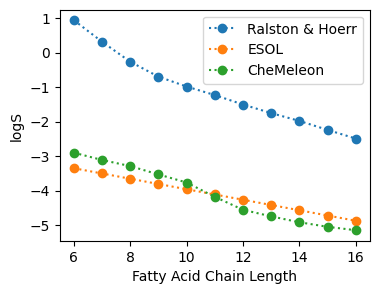

In [10]:
# plot true, esol, and chemeleon predictions against chain length
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4, 3))
plt.plot(chain_length, data["logS"], label="Ralston & Hoerr", marker="o", linestyle=':')
plt.plot(chain_length, esol_preds, label="ESOL", marker="o", linestyle=':')
plt.plot(chain_length, chemeleon_preds, label="CheMeleon", marker="o", linestyle=':')
plt.xlabel("Fatty Acid Chain Length")
plt.ylabel("logS")
plt.legend()

In [11]:
print("RMSE of ESOL refitted:", np.sqrt(np.mean((esol_preds - data["logS"]) ** 2)))
print("RMSE of Chemeleon:", np.sqrt(np.mean((chemeleon_preds - data["logS"]) ** 2)))

RMSE of ESOL refitted: 3.0864596724281594
RMSE of Chemeleon: 3.0475253195813936
